<a href="https://colab.research.google.com/github/arcctg/kpi-ml-lab5/blob/main/03_fmnist_clothing_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2: Fashion-MNIST Clothing Classification


#### Importing Required Libraries

We import the following libraries:
- **numpy (np)**: Array operations — reshaping, argmax, random sampling
- **matplotlib.pyplot (plt)**: Plotting images, training curves, and prediction charts
- **tensorflow (tf)**: Deep-learning backend powering Keras
- **tensorflow.keras.datasets.fashion_mnist**: Built-in loader for Fashion-MNIST (60 000 train + 10 000 test grayscale images of clothing items, 28×28)
- **tensorflow.keras.utils.to_categorical**: One-hot encoding for multi-class labels
- **tensorflow.keras.models / layers**: High-level API for building CNN architectures with `Conv2D`, `MaxPooling2D`, `Flatten`, and `Dense` layers

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


#### Loading the Fashion-MNIST Dataset

Fashion-MNIST is a drop-in replacement for the classic MNIST digit dataset, designed to be a more challenging benchmark. It is bundled inside Keras.

Key characteristics:
- **60 000 training** + **10 000 test** images
- **Grayscale** images of size **28 × 28** (single channel), same as MNIST
- **10 clothing categories**: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot
- Pixel values are `uint8` in **[0, 255]**
- Labels are integers in **[0, 9]**

Despite sharing the same image dimensions as MNIST, Fashion-MNIST is considerably harder: clothing items have more complex shapes, higher intra-class variation (many styles of shirts), and inter-class similarity (shirt vs. coat vs. pullover).

In [2]:
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Training set — images:", train_images.shape, "| labels:", train_labels.shape)
print("Test set     — images:", test_images.shape,  "| labels:", test_labels.shape)
print("Data type:", train_images.dtype)
print("Pixel value range: [{}, {}]".format(train_images.min(), train_images.max()))

Training set — images: (60000, 28, 28) | labels: (60000,)
Test set     — images: (10000, 28, 28) | labels: (10000,)
Data type: uint8
Pixel value range: [0, 255]


#### Visualising the First 25 Training Images

We display a 5 × 5 grid of the first 25 training images with their class names.

This serves as a sanity check and gives an intuition about the dataset. Notice how some categories look quite similar (e.g. Shirt vs. T-shirt vs. Coat) — this is what makes Fashion-MNIST a harder benchmark than digit MNIST.

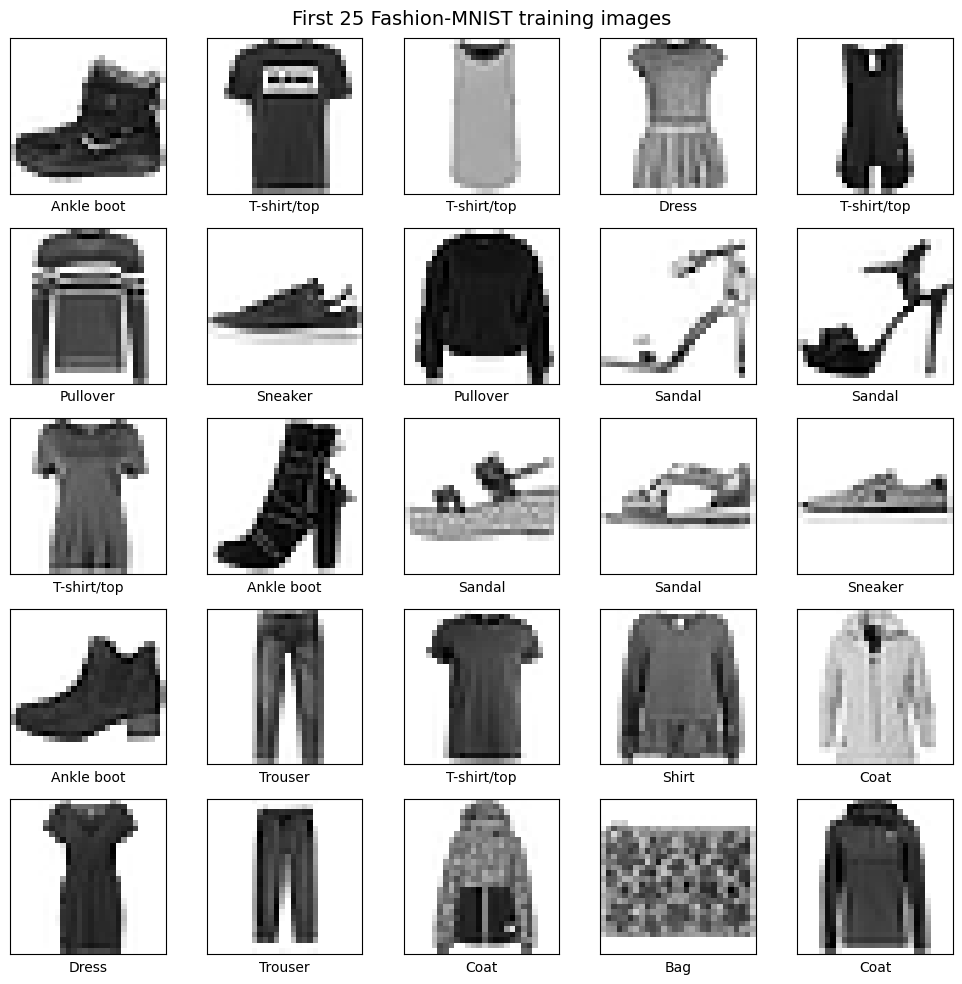

In [3]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.suptitle("First 25 Fashion-MNIST training images", fontsize=14)
plt.tight_layout()
plt.show()

#### Data Preprocessing

Three transformations are applied:

**1. Add channel dimension**
Raw shape is `(60000, 28, 28)`. We reshape to `(60000, 28, 28, 1)` because `Conv2D` expects a 4-D tensor with an explicit channel axis. For grayscale images the channel count is 1.

**2. Normalise to [0, 1]**
Divide by 255 and cast to `float32`. This keeps inputs in the same small numeric range as the initial random weights, accelerating gradient convergence.

**3. One-hot encode labels**
`to_categorical` converts each integer label to a binary vector of length 10, as required by `categorical_crossentropy`.

In [4]:
# Add channel dimension + normalise
train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255
test_images  = test_images.reshape((10000,  28, 28, 1)).astype('float32') / 255

# One-hot encode labels
train_labels = to_categorical(train_labels, 10)
test_labels  = to_categorical(test_labels, 10)

print("train_images shape:", train_images.shape, "| dtype:", train_images.dtype)
print("train_labels shape:", train_labels.shape)

train_images shape: (60000, 28, 28, 1) | dtype: float32
train_labels shape: (60000, 10)


#### Defining the CNN Architecture

Although Fashion-MNIST shares the same 28×28 grayscale format as digit MNIST, a simple Dense network only reaches ~87 % accuracy. A CNN improves this to ~90–91 % by learning spatial features (edges, textures, shapes) through convolutional filters.

| Layer | Output shape | Role |
|-------|-------------|------|
| Conv2D(32, 3×3, relu) | (26, 26, 32) | Learns 32 low-level filters (edges, contours) |
| MaxPooling2D(2×2) | (13, 13, 32) | Halves spatial dimensions, adds translation invariance |
| Conv2D(64, 3×3, relu) | (11, 11, 64) | Learns 64 higher-level feature combinations |
| MaxPooling2D(2×2) | (5, 5, 64) | Further downsampling |
| Flatten | (1600,) | Unrolls feature maps into a vector |
| Dense(64, relu) | (64,) | Non-linear classification head |
| Dense(10, softmax) | (10,) | Probability distribution over 10 classes |

This architecture is slightly smaller than the CIFAR-10 CNN (2 conv layers instead of 3) because the input is single-channel grayscale and the shapes are simpler than real-world colour photographs.

In [5]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)

#### Compiling the Model

- **Optimizer — `adam`**: Adaptive Moment Estimation. Combines RMSProp's adaptive learning rate with SGD momentum. The default choice for CNN training.
- **Loss — `categorical_crossentropy`**: Standard loss for multi-class classification with one-hot encoded labels.
- **Metric — `accuracy`**: Fraction of correctly classified samples, reported for monitoring.

In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#### Training the Model

Training parameters:

- **`epochs=10`** — Fashion-MNIST is simpler than CIFAR-10 (grayscale 28×28 with uniform backgrounds vs. RGB 32×32 with complex real-world scenes). The CNN converges faster: validation accuracy typically plateaus around epoch 8–10 and further training mainly increases overfitting. Therefore 10 epochs is a good balance between accuracy and avoiding over-training, compared to 15 epochs used for the more complex CIFAR-10.
- **`batch_size=64`** — mini-batch gradient descent for stable yet frequent weight updates.
- **`validation_split=0.1`** — 6 000 images withheld for generalisation monitoring.

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_images,
    train_labels,
    epochs=40,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/40
844/844 ━━━━━━━━━━━━━━━━━━━━ 150s 172ms/step - accuracy: 0.7905 - loss: 0.5882 - val_accuracy: 0.8730 - val_loss: 0.3368
Epoch 2/40
844/844 ━━━━━━━━━━━━━━━━━━━━ 146s 172ms/step - accuracy: 0.8532 - loss: 0.3987 - val_accuracy: 0.8850 - val_loss: 0.3212
Epoch 3/40
844/844 ━━━━━━━━━━━━━━━━━━━━ 146s 173ms/step - accuracy: 0.8701 - loss: 0.3532 - val_accuracy: 0.8968 - val_loss: 0.2824
Epoch 4/40
844/844 ━━━━━━━━━━━━━━━━━━━━ 198s 168ms/step - accuracy: 0.8774 - loss: 0.3288 - val_accuracy: 0.8912 - val_loss: 0.2832
Epoch 5/40
844/844 ━━━━━━━━━━━━━━━━━━━━ 207s 174ms/step - accuracy: 0.8872 - loss: 0.3059 - val_accuracy: 0.8883 - val_loss: 0.2931
Epoch 6/40
844/844 ━━━━━━━━━━━━━━━━━━━━ 101s 120ms/step - accuracy: 0.8903 - loss: 0.2960 - val_accuracy: 0.9040 - val_loss: 0.2645
Epoch 7/40
844/844 ━━━━━━━━━━━━━━━━━━━━ 74s 88ms/step - accuracy: 0.8959 - loss: 0.2847 - val_accuracy: 0.9082 - val_loss: 0.2536
Epoch 8/40
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 89ms/step - accuracy: 0.8971 - los

#### Training History — Loss and Accuracy Curves

We plot accuracy and loss for both training and validation sets.

- **Accuracy**: both curves should rise and converge. A growing gap signals overfitting.
- **Loss**: both curves should fall. Rising validation loss with falling training loss means the model is memorising.

For Fashion-MNIST with this CNN, mild overfitting may appear after ~8 epochs as training accuracy continues to climb while validation accuracy saturates around 90–91 %.

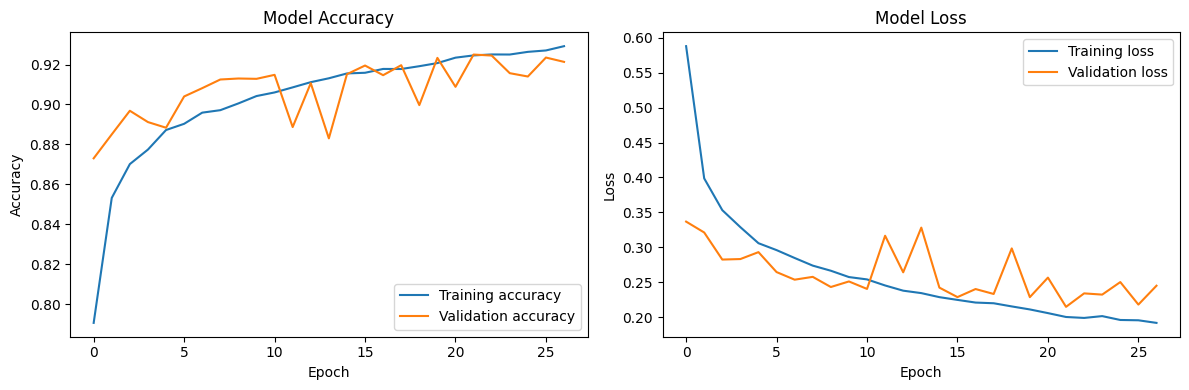

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Training accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Training loss')
axes[1].plot(history.history['val_loss'], label='Validation loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

#### Evaluating on the Test Set

We evaluate the trained model on the held-out 10 000-image test set to get an unbiased performance estimate.

Expected test accuracy: approximately **~90–91 %**. This is lower than MNIST (~98 %) because clothing items have more complex shapes and higher inter-class similarity, but higher than CIFAR-10 (~70 %) because the images are simpler (grayscale, centred objects, uniform background).

In [9]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}  ({test_acc * 100:.2f} %)")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9178 - loss: 0.2349
Test loss:     0.2349
Test accuracy: 0.9178  (91.78 %)


#### Visualising Predictions on Test Images

We randomly sample 10 images from the test set and display:
- **Left**: the 28×28 image with true and predicted labels. Correct predictions in green, incorrect in red.
- **Right**: a horizontal bar chart of the model's confidence across all 10 classes. The predicted class is highlighted in red.

Common confusion pairs include Shirt vs. T-shirt/top, Pullover vs. Coat, and Sneaker vs. Ankle boot.

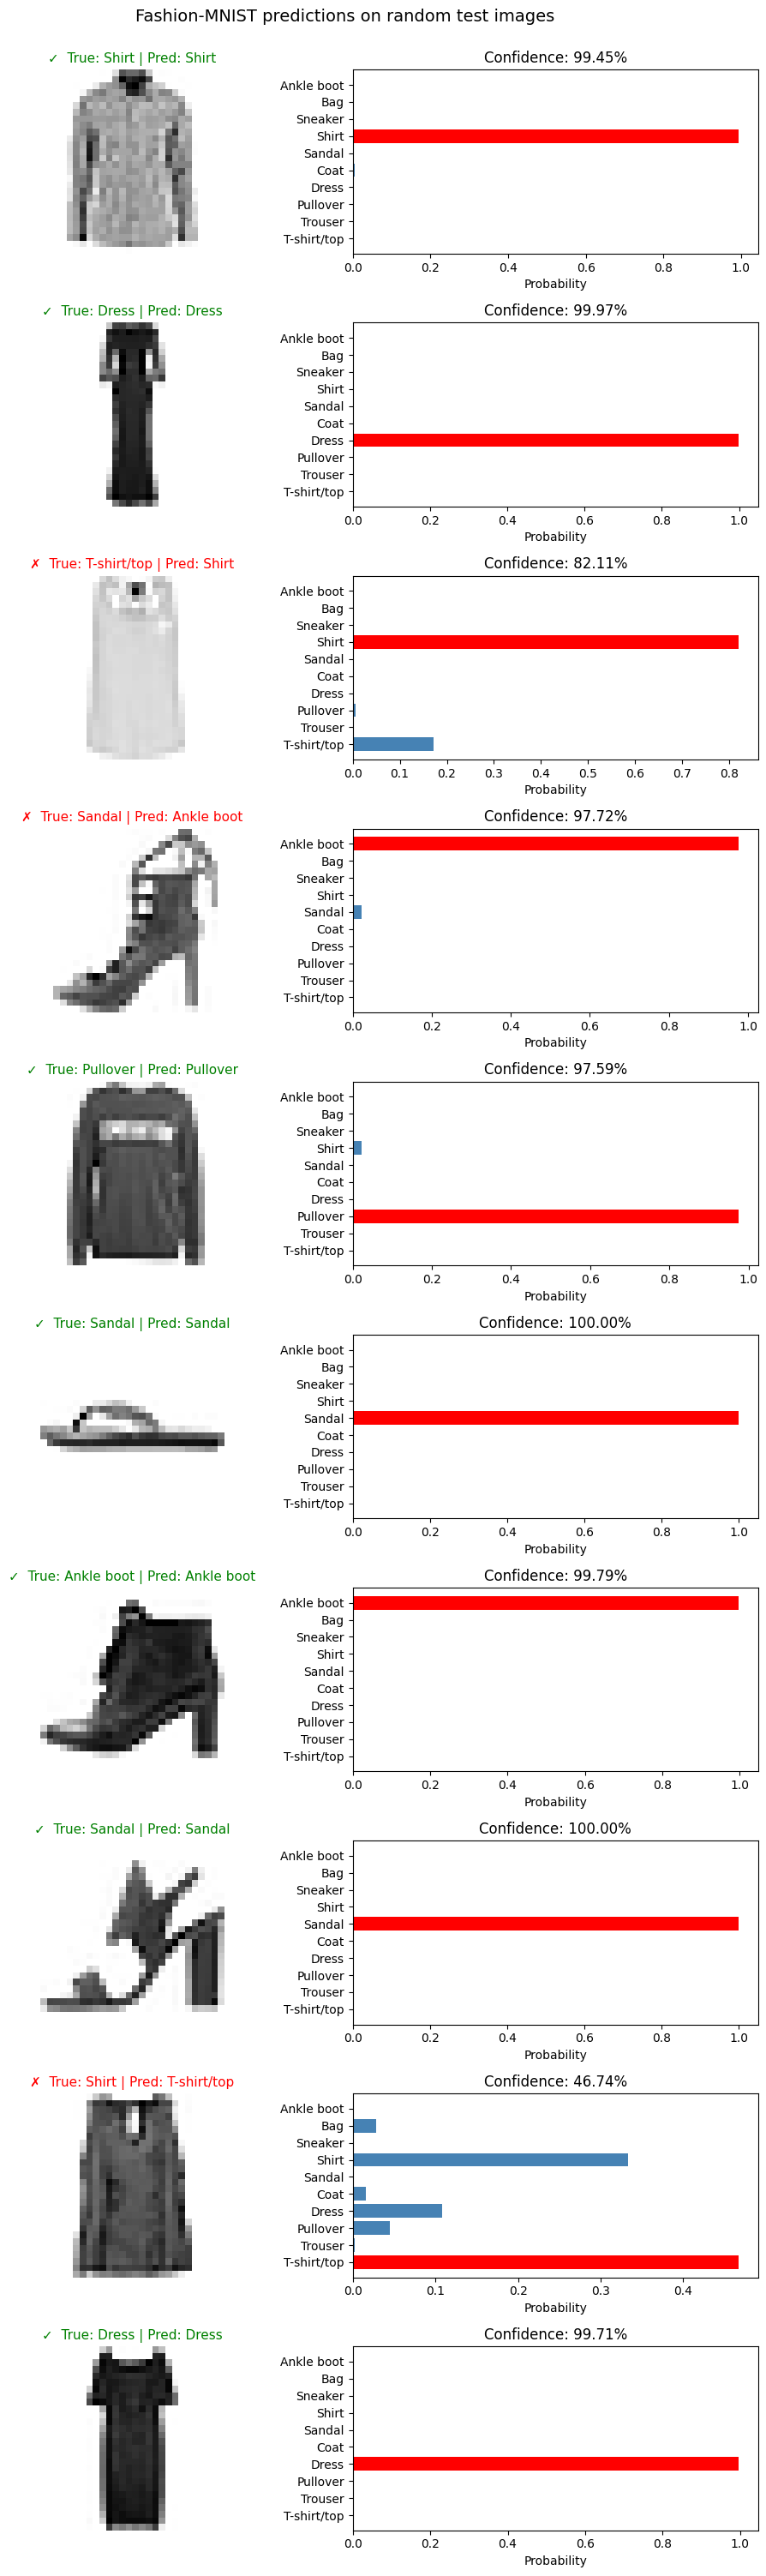

In [10]:
np.random.seed(42)
indices = np.random.choice(len(test_images), 10, replace=False)

fig, axes = plt.subplots(10, 2, figsize=(10, 30))

for row, idx in enumerate(indices):
    img = test_images[idx]
    true_label = np.argmax(test_labels[idx])
    preds = model.predict(img.reshape(1, 28, 28, 1), verbose=0)[0]
    predicted = np.argmax(preds)
    is_correct = predicted == true_label

    # Image
    axes[row, 0].imshow(img.reshape(28, 28), cmap=plt.cm.binary)
    colour = 'green' if is_correct else 'red'
    mark = '\u2713' if is_correct else '\u2717'
    axes[row, 0].set_title(
        f"{mark}  True: {class_names[true_label]} | Pred: {class_names[predicted]}",
        fontsize=11, color=colour
    )
    axes[row, 0].axis('off')

    # Confidence bar chart
    bar_colors = ['red' if j == predicted else 'steelblue' for j in range(10)]
    axes[row, 1].barh(range(10), preds, color=bar_colors)
    axes[row, 1].set_yticks(range(10))
    axes[row, 1].set_yticklabels(class_names)
    axes[row, 1].set_xlabel('Probability')
    axes[row, 1].set_title(f'Confidence: {preds[predicted]:.2%}')

plt.suptitle('Fashion-MNIST predictions on random test images', fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

#### Saving the Trained Model

We save the complete model (architecture + weights + optimiser state) in the `.keras` format for later use without retraining.

In [11]:
model.save('fmnist_model.keras')
print("Model saved to: fmnist_model.keras")

Model saved to: fmnist_model.keras


#### Conclusions

In this task we designed and trained a **Convolutional Neural Network** to classify 28×28 grayscale images of clothing items from the Fashion-MNIST dataset into 10 categories.

**Key results:**
- The 2-layer CNN (Conv2D 32 → Conv2D 64 → Dense 64 → Dense 10) achieves approximately **~90–91 %** test accuracy after 10 epochs.
- This is a clear improvement over a Dense-only network (~87 %), confirming that convolutional layers help even on small grayscale images.

**Observations:**
- The most commonly confused classes are visually similar clothing types: Shirt vs. T-shirt/top, Pullover vs. Coat. These categories overlap significantly in shape and texture.
- Mild overfitting is visible after ~8 epochs. Techniques like dropout or data augmentation could improve generalisation.

**Cross-task comparison:**

| Dataset | Architecture | Test accuracy | Difficulty |
|---------|-------------|--------------|------------|
| MNIST (digits) | Dense 512 → 10 | ~98 % | Low — clean digits on blank background |
| Fashion-MNIST | CNN (2 conv) | ~90 % | Medium — complex shapes, similar classes |
| CIFAR-10 | CNN (3 conv) | ~70 % | High — colour photos, complex backgrounds |

This progression illustrates how image complexity demands increasingly powerful architectures.